In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df2=pd.read_excel(r"D:\data analyst project\Uber trip analysis\Uber Trip Details.xlsx")

In [5]:
df2.head()

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Vehicle,Payment_type
0,1,2024-06-01 00:42:50,2024-06-01 01:04:33,1,5.60,79,226,19.5,2.0,UberX,Uber Pay
1,2,2024-06-01 00:06:29,2024-06-01 00:13:22,1,1.72,142,186,8.0,0.0,Uber Black,Cash
2,3,2024-06-01 00:08:05,2024-06-01 00:21:33,1,3.41,229,238,13.0,0.0,Uber Black,Cash
3,4,2024-06-01 00:28:20,2024-06-01 00:37:46,1,1.81,188,35,9.0,0.0,UberX,Cash
4,5,2024-06-01 00:38:05,2024-06-01 00:45:05,1,1.89,100,137,8.0,0.0,Uber Black,Cash


2. Check dataset info & missing values

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103728 entries, 0 to 103727
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Trip ID          103728 non-null  int64         
 1   Pickup Time      103728 non-null  datetime64[ns]
 2   Drop Off Time    103728 non-null  datetime64[ns]
 3   passenger_count  103728 non-null  int64         
 4   trip_distance    103728 non-null  float64       
 5   PULocationID     103728 non-null  int64         
 6   DOLocationID     103728 non-null  int64         
 7   fare_amount      103728 non-null  float64       
 8   Surge Fee        103728 non-null  float64       
 9   Vehicle          103728 non-null  object        
 10  Payment_type     103728 non-null  object        
dtypes: datetime64[ns](2), float64(3), int64(4), object(2)
memory usage: 8.7+ MB


In [8]:
df2.isnull().sum()

Trip ID            0
Pickup Time        0
Drop Off Time      0
passenger_count    0
trip_distance      0
PULocationID       0
DOLocationID       0
fare_amount        0
Surge Fee          0
Vehicle            0
Payment_type       0
dtype: int64

3. Total number of trips

In [10]:
df2['Trip ID'].nunique()

103728

4. Average fare amount

In [12]:
df2['fare_amount'].mean()

12.998336514730832

5. Maximum & Minimum trip distance

In [14]:
df2['trip_distance'].max()

144.1

In [15]:
df2['trip_distance'].min()

1.01

6. Most common payment type

In [17]:
df2['Payment_type'].value_counts()

Payment_type
Uber Pay      69530
Cash          33434
Amazon Pay      584
Google Pay      180
Name: count, dtype: int64

7. Average passengers per trip

In [19]:
df2['passenger_count'].mean()

1.4121355853771402

8. Average fare by payment type

In [21]:
df2.groupby(['Payment_type'])['fare_amount'].mean().sort_values(ascending=False)

Payment_type
Google Pay    15.108333
Amazon Pay    14.650685
Cash          13.260663
Uber Pay      12.852854
Name: fare_amount, dtype: float64

9. Total revenue generated

In [23]:
df2['fare_amount'].sum()

1348291.4499999997

In [24]:
df2['Drop Off Time']=pd.to_datetime(df2['Drop Off Time'])
df2['Pickup Time']=pd.to_datetime(df2['Pickup Time'])

df2['trip duration']=(df2['Drop Off Time']-df2['Pickup Time']).dt.total_seconds()/60
df2['trip duration']

0         21.716667
1          6.883333
2         13.466667
3          9.433333
4          7.000000
            ...    
103723    17.566667
103724     5.833333
103725     4.283333
103726     8.766667
103727    11.100000
Name: trip duration, Length: 103728, dtype: float64

In [25]:
df2.groupby(['passenger_count'])['fare_amount'].sum()

passenger_count
1    1065571.45
2     166878.00
3      40847.50
4      15224.50
5      31590.00
6      28180.00
Name: fare_amount, dtype: float64

In [26]:
df2['Pickup hour']=df2['Pickup Time'].dt.hour
df2['Pickup hour'].value_counts()

Pickup hour
15    7908
17    7801
14    7694
16    7576
13    7226
12    7163
18    7070
11    6602
10    5970
9     5641
19    5479
8     4967
7     4135
20    3694
21    3037
6     2834
22    2584
23    2045
0     1346
5      982
1      829
2      477
3      337
4      331
Name: count, dtype: int64

In [27]:
df2['fare per km']=df2['fare_amount']/df2['trip_distance']
df2['fare per km'].mean()

4.4271711708709995

In [28]:
df2['PULocationID'].value_counts().head(10)

PULocationID
186    4475
236    4459
237    4124
140    3955
238    3752
48     3722
141    3617
142    3519
263    3393
170    3305
Name: count, dtype: int64

In [30]:
df2['hour']=df2['Pickup Time'].dt.hour
df2.groupby(['hour'])['fare_amount'].sum().sort_values(ascending=False)

hour
17    106107.50
15    104006.50
16    101719.50
14     98350.20
18     91912.00
13     90300.00
12     89828.00
11     83968.50
10     75795.24
19     70633.00
9      67202.50
8      56963.00
20     51128.46
7      47429.70
21     44237.00
22     39802.00
23     31765.00
6      30775.00
0      22025.00
1      13718.00
5      11864.00
2       7684.23
3       5755.50
4       5321.62
Name: fare_amount, dtype: float64

In [31]:
df2[['trip_distance','fare_amount']].corr()

,trip_distance,fare_amount
trip_distance,1.00000,0.97462
fare_amount,0.97462,1.00000


In [32]:
Q1=df2['fare_amount'].quantile(0.25)
Q3=df2['fare_amount'].quantile(0.75)
IQR=Q3-Q1
outliers_lower=df2['fare_amount']<1.5*Q1
outliers_upper=df2['fare_amount']>1.5*Q3
outliers=outliers_lower|outliers_upper
outliers

0         False
1          True
2         False
3          True
4          True
          ...  
103723     True
103724     True
103725     True
103726     True
103727    False
Name: fare_amount, Length: 103728, dtype: bool

In [33]:
revenue=df2.groupby('Payment_type')['fare_amount'].sum()
percentage=(revenue/revenue.sum())*100
percentage

Payment_type
Amazon Pay     0.634581
Cash          32.882876
Google Pay     0.201700
Uber Pay      66.280844
Name: fare_amount, dtype: float64

In [34]:
df2.sort_values(['trip_distance','fare_amount'],ascending=False).head(10)

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Vehicle,Payment_type,trip duration,Pickup hour,fare per km,hour
92204,103565,2024-06-28 10:50:50,2024-06-28 19:42:41,1,144.10,148,61,563.79,0.00,UberX,Uber Pay,531.850000,10,3.912491,10
13068,14781,2024-06-05 17:04:56,2024-06-05 19:46:04,1,125.50,186,39,328.50,74.51,UberX,Uber Pay,161.133333,17,2.617530,17
30385,32353,2024-06-11 10:17:39,2024-06-11 14:12:42,1,62.40,162,162,204.00,41.90,Uber Black,Uber Pay,235.050000,10,3.269231,10
79558,88894,2024-06-25 10:11:52,2024-06-25 14:19:43,1,61.37,162,162,212.50,45.61,Uber Green,Uber Pay,247.850000,10,3.462604,10
40397,43342,2024-06-14 14:07:19,2024-06-14 15:03:25,1,51.20,132,265,131.00,100.00,UberX,Uber Pay,56.100000,14,2.558594,14
98799,111181,2024-06-29 21:46:38,2024-06-29 22:38:44,1,47.09,44,101,121.50,2.75,Uber Green,Uber Pay,52.100000,21,2.580166,21
53093,58035,2024-06-18 10:03:08,2024-06-18 13:03:43,1,46.32,162,228,157.00,32.06,UberXL,Uber Pay,180.583333,10,3.389465,10
83212,93151,2024-06-25 22:24:55,2024-06-25 23:35:05,1,45.91,44,240,124.00,2.75,UberX,Uber Pay,70.166667,22,2.700937,22
70453,78275,2024-06-23 09:59:37,2024-06-23 14:52:33,1,45.47,162,74,199.00,40.46,UberX,Uber Pay,292.933333,9,4.376512,9
72223,80339,2024-06-23 15:55:35,2024-06-23 17:12:27,1,44.61,204,259,117.50,2.75,UberX,Uber Pay,76.866667,15,2.633939,15


In [35]:
total_rev=0

for i in df2['fare_amount']:
    total_rev=total_rev+i
print("Total Revenue: ",total_rev)

Total Revenue:  1348291.4499999997


In [36]:
count=0
for i in df2["fare_amount"]:
    if i>10:
        count+=i

print("Trips greater than 10km ",count)

Trips greater than 10km  934090.9500000001


In [37]:
fare=df2["fare_amount"][0]
for i in df2["fare_amount"]:
    if i>fare:
        fare=i

print("Maximum Fare: ",fare)

Maximum Fare:  563.79


In [38]:
min_dis=df2["trip_distance"][0]
for i in df2['trip_distance']:
    if min_dis>i:
        min_dis=i

print("Minimum distance : ",min_dis)

Minimum distance :  1.01


In [40]:
rev_tag=[]
for i in df2["fare_amount"]:
    if i>50:
        rev_tag.append("High")
    else:
        rev_tag.append("Low")
df2["Revenue tag"]=rev_tag

In [41]:
df2["Revenue tag"]

0         Low
1         Low
2         Low
3         Low
4         Low
         ... 
103723    Low
103724    Low
103725    Low
103726    Low
103727    Low
Name: Revenue tag, Length: 103728, dtype: object

In [42]:
pymt_type=0
for i in df2["Payment_type"]:
    if i=="Cash":
        pymt_type+=1

print(pymt_type)

33434


In [43]:
pymt_type=0
for i in df2["Payment_type"]:
    if i=="Uber Pay":
        pymt_type+=1

print(pymt_type)

69530


In [49]:
long_trips=[]
for i in df2["trip duration"]:
    if i > 20:
        long_trips.append(i)

print(len(long_trips))

14879


In [54]:
df2.head()

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Vehicle,Payment_type,trip duration,Pickup hour,fare per km,hour,Revenue tag
0,1,2024-06-01 00:42:50,2024-06-01 01:04:33,1,5.60,79,226,19.5,2.0,UberX,Uber Pay,21.716667,0,3.482143,0,Low
1,2,2024-06-01 00:06:29,2024-06-01 00:13:22,1,1.72,142,186,8.0,0.0,Uber Black,Cash,6.883333,0,4.651163,0,Low
2,3,2024-06-01 00:08:05,2024-06-01 00:21:33,1,3.41,229,238,13.0,0.0,Uber Black,Cash,13.466667,0,3.812317,0,Low
3,4,2024-06-01 00:28:20,2024-06-01 00:37:46,1,1.81,188,35,9.0,0.0,UberX,Cash,9.433333,0,4.972376,0,Low
4,5,2024-06-01 00:38:05,2024-06-01 00:45:05,1,1.89,100,137,8.0,0.0,Uber Black,Cash,7.000000,0,4.232804,0,Low


Text(0, 0.5, 'Revenue')

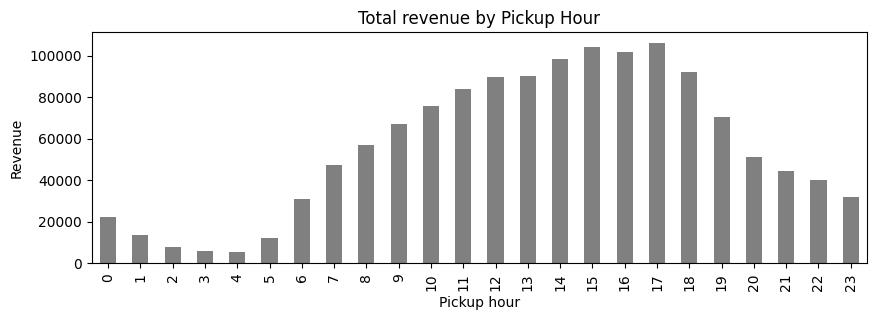

In [157]:
hourly_rev=df2.groupby(["Pickup hour"])["fare_amount"].sum()
plt.figure(figsize=(10,3))
hourly_rev.plot(kind='bar',color='Grey')
plt.title('Total revenue by Pickup Hour')
plt.ylabel('Revenue')

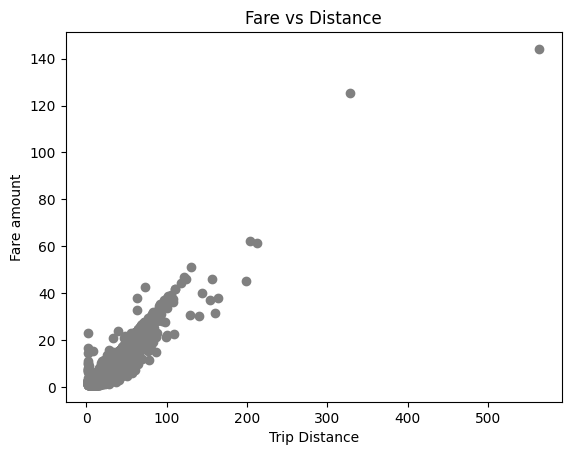

In [151]:
plt.scatter(df2['fare_amount'],df2['trip_distance'],color='Grey')
plt.title('Fare vs Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Fare amount')
plt.show()

([<matplotlib.patches.Wedge at 0x1edbb09f7d0>,
 [Text(-0.5608697543011798, 0.9462690519667937, 'Uber Pay'),
  Text(0.538825657143049, -0.9589926544058414, 'Cash'),
  Text(1.099550439345944, -0.031445688641547724, 'Amazon Pay'),
  Text(1.0999836532075675, -0.0059968888712382835, 'Google Pay')],
 [Text(-0.3059289568915526, 0.5161467556182511, '67.0%'),
  Text(0.2939049038962085, -0.5230869024031861, '32.2%'),
  Text(0.5997547850977877, -0.017152193804480576, '0.6%'),
  Text(0.599991083567764, -0.0032710302934026996, '0.2%')])

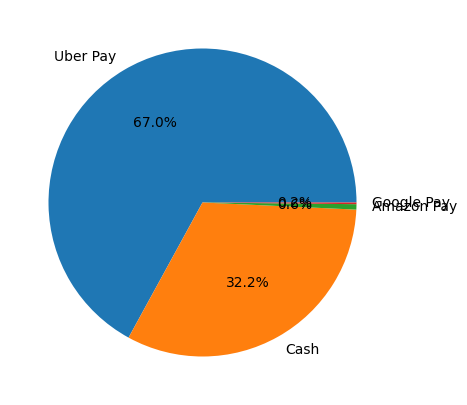

In [179]:
paymt_count=df2['Payment_type'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(paymt_count,labels=paymt_count.index,autopct='%1.1f%%')

Text(0.5, 1.0, 'Average fare amount by Person Count')

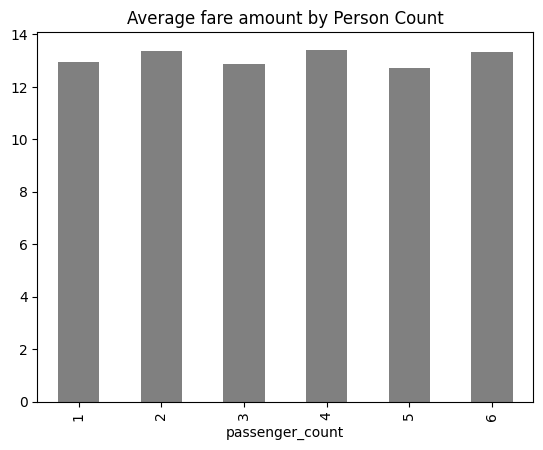

In [193]:
avg_fare=df2.groupby(['passenger_count'])['fare_amount'].mean()
avg_fare.plot(kind='bar',color='grey')
plt.title('Average fare amount by Person Count')

<Axes: >

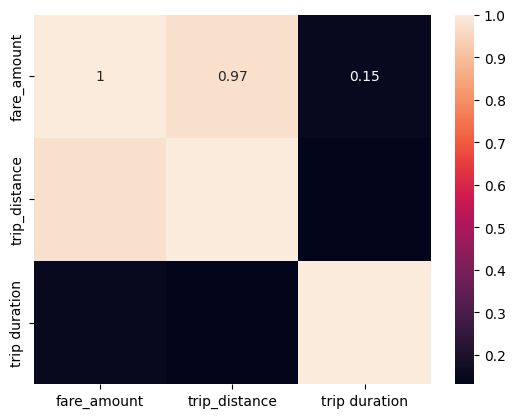

In [207]:
sns.heatmap(df2[['fare_amount','trip_distance','trip duration']].corr(), annot=True)

Text(0.5, 1.0, 'Top 10 Pickup Location By Revenue')

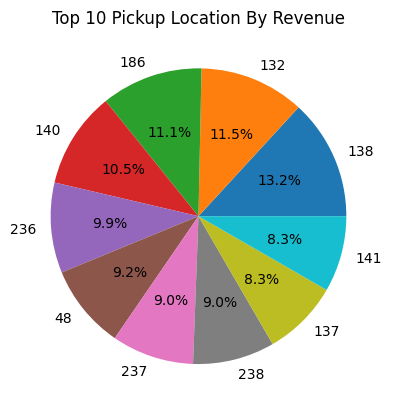

In [270]:
top_10=df2.groupby(['PULocationID'])['fare_amount'].sum().sort_values(ascending=False).head(10)
plt.pie(top_10,labels=top_10.index,autopct='%1.1f%%')
plt.title('Top 10 Pickup Location By Revenue')